# Memory Hierarchy

Develop an experiment that exposes the latency and bandwidth effects of the CPU memory hierarchy.

## Objectives

Relate working-set size and access pattern to cache and main-memory behavior.

## Background

Caches exploit temporal and spatial locality; access patterns that exceed or bypass them expose slower memory levels.

## Prediction

A dependent randomized pointer-chasing workload should show increasing access latency as its working set exceeds successive cache capacities. The first transition is expected around the private L1 data-cache capacity, another around the private L2 capacity, and a further transition near the shared L3 capacity. Because CPUs 5 and 15 belong to L3 domains of 8 MiB and 16 MiB respectively, working sets between those capacities may exhibit lower latency on CPU 15. Working sets substantially larger than both L3 caches should approach main-memory latency on both CPUs.

## Environment

In [1]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [2]:
from pathlib import Path

import pandas as pd


def read_optional(path: Path) -> str | None:
    try:
        return path.read_text().strip()
    except (FileNotFoundError, PermissionError, OSError):
        return None


def cache_entries(cpu_id: int) -> list[dict[str, object]]:
    cache_root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}/cache")
    rows: list[dict[str, object]] = []

    for index_path in sorted(cache_root.glob("index*")):
        rows.append(
            {
                "cpu": cpu_id,
                "index": index_path.name,
                "level": read_optional(index_path / "level"),
                "type": read_optional(index_path / "type"),
                "size": read_optional(index_path / "size"),
                "line_size_bytes": read_optional(index_path / "coherency_line_size"),
                "ways": read_optional(index_path / "ways_of_associativity"),
                "sets": read_optional(index_path / "number_of_sets"),
                "shared_cpu_list": read_optional(index_path / "shared_cpu_list"),
            }
        )

    return rows


REPRESENTATIVE_CPUS = [5, 15]

cache_topology = pd.DataFrame(
    row for cpu_id in REPRESENTATIVE_CPUS for row in cache_entries(cpu_id)
)

for column in [
    "level",
    "line_size_bytes",
    "ways",
    "sets",
]:
    cache_topology[column] = pd.to_numeric(
        cache_topology[column],
        errors="coerce",
    ).astype("Int64")

cache_topology

,cpu,index,level,type,size,line_size_bytes,ways,sets,shared_cpu_list
0,5,index0,1,Data,64K,64,4,256,5
1,5,index1,1,Instruction,64K,64,4,256,5
2,5,index2,2,Unified,2048K,64,8,4096,5
3,5,index3,3,Unified,8192K,64,16,8192,0-9
4,15,index0,1,Data,64K,64,4,256,15
5,15,index1,1,Instruction,64K,64,4,256,15
6,15,index2,2,Unified,2048K,64,8,4096,15
7,15,index3,3,Unified,16384K,64,16,16384,10-19


In [3]:
from pathlib import Path


def cpu_metadata(cpu_id: int) -> dict[str, object]:
    root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}")

    return {
        "cpu": cpu_id,
        "cluster_id": read_optional(root / "topology/cluster_id"),
        "max_frequency_khz": read_optional(root / "cpufreq/cpuinfo_max_freq"),
        "current_frequency_khz": read_optional(root / "cpufreq/scaling_cur_freq"),
    }


representative_cpu_metadata = pd.DataFrame(
    cpu_metadata(cpu_id) for cpu_id in REPRESENTATIVE_CPUS
)

representative_cpu_metadata

,cpu,cluster_id,max_frequency_khz,current_frequency_khz
0,5,56,3900000,3900000
1,15,1144,3900000,3900000


In [4]:
import ctypes
import hashlib
import shutil
import subprocess
import textwrap
from pathlib import Path


C_SOURCE = r"""
#define _GNU_SOURCE

#include <stdint.h>
#include <stddef.h>
#include <stdlib.h>
#include <time.h>

typedef struct __attribute__((aligned(64))) {
    uint32_t next;
    unsigned char padding[60];
} Node;

_Static_assert(sizeof(Node) == 64, "Node must occupy one cache line");

static volatile uint32_t pointer_chase_sink = 0;

static uint64_t xorshift64(uint64_t *state) {
    uint64_t value = *state;
    value ^= value << 13;
    value ^= value >> 7;
    value ^= value << 17;
    *state = value;
    return value;
}

static uint64_t elapsed_ns(
    const struct timespec *start,
    const struct timespec *end
) {
    return (
        (uint64_t)(end->tv_sec - start->tv_sec) * 1000000000ULL
        + (uint64_t)(end->tv_nsec - start->tv_nsec)
    );
}

/*
 * Return nanoseconds per dependent load.
 *
 * Every node occupies one 64-byte cache line. The nodes form one randomized
 * cycle, so each loaded index determines the location of the next load.
 */
double pointer_chase(
    size_t working_set_bytes,
    uint64_t accesses,
    uint64_t seed
) {
    if (working_set_bytes < sizeof(Node) || accesses == 0) {
        return -1.0;
    }

    size_t node_count = working_set_bytes / sizeof(Node);
    size_t allocation_bytes = node_count * sizeof(Node);

    Node *nodes = aligned_alloc(64, allocation_bytes);
    uint32_t *permutation = malloc(node_count * sizeof(uint32_t));

    if (nodes == NULL || permutation == NULL) {
        free(nodes);
        free(permutation);
        return -2.0;
    }

    for (size_t index = 0; index < node_count; ++index) {
        permutation[index] = (uint32_t)index;
    }

    uint64_t random_state = seed == 0 ? 1 : seed;

    for (size_t index = node_count - 1; index > 0; --index) {
        size_t other = xorshift64(&random_state) % (index + 1);

        uint32_t temporary = permutation[index];
        permutation[index] = permutation[other];
        permutation[other] = temporary;
    }

    for (size_t index = 0; index < node_count; ++index) {
        uint32_t current = permutation[index];
        uint32_t next = permutation[(index + 1) % node_count];
        nodes[current].next = next;
    }

    uint32_t current = permutation[0];

    /*
     * Warm up one complete traversal. This faults in the pages and fills
     * whatever cache level can retain the working set.
     */
    for (size_t index = 0; index < node_count; ++index) {
        current = nodes[current].next;
    }

    struct timespec start;
    struct timespec end;

    clock_gettime(CLOCK_MONOTONIC_RAW, &start);

    for (uint64_t index = 0; index < accesses; ++index) {
        current = nodes[current].next;
    }

    clock_gettime(CLOCK_MONOTONIC_RAW, &end);

    pointer_chase_sink = current;

    uint64_t duration_ns = elapsed_ns(&start, &end);

    free(permutation);
    free(nodes);

    return (double)duration_ns / (double)accesses;
}

static volatile uint64_t bandwidth_sink = 0;

double sequential_read_bandwidth(
    size_t working_set_bytes,
    uint64_t passes
) {
    if (working_set_bytes < sizeof(uint64_t) || passes == 0) {
        return -1.0;
    }

    size_t element_count = working_set_bytes / sizeof(uint64_t);
    size_t allocation_bytes = element_count * sizeof(uint64_t);

    uint64_t *values = aligned_alloc(64, allocation_bytes);

    if (values == NULL) {
        return -2.0;
    }

    for (size_t index = 0; index < element_count; ++index) {
        values[index] = (uint64_t)index + 1;
    }

    uint64_t sum = 0;

    /* Warm up and fault in all pages. */
    for (size_t index = 0; index < element_count; ++index) {
        sum += values[index];
    }

    struct timespec start;
    struct timespec end;

    clock_gettime(CLOCK_MONOTONIC_RAW, &start);

    for (uint64_t pass = 0; pass < passes; ++pass) {
        for (size_t index = 0; index < element_count; ++index) {
            sum += values[index];
        }
    }

    clock_gettime(CLOCK_MONOTONIC_RAW, &end);

    bandwidth_sink = sum;

    uint64_t duration_ns = elapsed_ns(&start, &end);
    double bytes_read = (double)allocation_bytes * (double)passes;
    double seconds = (double)duration_ns / 1000000000.0;

    free(values);

    return bytes_read / seconds;
}
"""


compiler = shutil.which("cc") or shutil.which("clang") or shutil.which("gcc")

if compiler is None:
    raise RuntimeError("No C compiler found: expected cc, clang, or gcc")

source_hash = hashlib.sha256(C_SOURCE.encode()).hexdigest()[:12]
build_directory = Path("/tmp/dgx-spark-lab-memory-hierarchy")
build_directory.mkdir(parents=True, exist_ok=True)

source_path = build_directory / f"pointer_chase_{source_hash}.c"
library_path = build_directory / f"pointer_chase_{source_hash}.so"

source_path.write_text(textwrap.dedent(C_SOURCE))

compile_result = subprocess.run(
    [
        compiler,
        "-O3",
        "-std=c11",
        "-shared",
        "-fPIC",
        "-Wall",
        "-Wextra",
        str(source_path),
        "-o",
        str(library_path),
    ],
    capture_output=True,
    text=True,
    check=False,
)

if compile_result.returncode != 0:
    raise RuntimeError(f"Pointer-chase compilation failed:\n{compile_result.stderr}")

print(f"Compiler: {compiler}")
print(f"Library: {library_path}")

Compiler: /usr/bin/cc
Library: /tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_fcc85a7b21ce.so


In [5]:
pointer_chase_library = ctypes.CDLL(str(library_path))

pointer_chase_native = pointer_chase_library.pointer_chase
pointer_chase_native.argtypes = [
    ctypes.c_size_t,
    ctypes.c_uint64,
    ctypes.c_uint64,
]
pointer_chase_native.restype = ctypes.c_double


def measure_pointer_chase(
    working_set_bytes: int,
    accesses: int,
    seed: int,
) -> float:
    """Return nanoseconds per dependent cache-line load."""
    result = pointer_chase_native(
        working_set_bytes,
        accesses,
        seed,
    )

    if result < 0:
        raise RuntimeError(f"Native pointer chase failed with result {result}")

    return float(result)

In [6]:
from collections.abc import Iterator
from contextlib import contextmanager


@contextmanager
def pinned_to_cpu(cpu_id: int) -> Iterator[None]:
    """Temporarily restrict the notebook kernel to one logical CPU."""
    original_affinity = os.sched_getaffinity(0)

    if cpu_id not in original_affinity:
        raise ValueError(
            f"CPU {cpu_id} is unavailable; current affinity is "
            f"{sorted(original_affinity)}"
        )

    try:
        os.sched_setaffinity(0, {cpu_id})

        if os.sched_getaffinity(0) != {cpu_id}:
            raise RuntimeError(f"Could not pin process to CPU {cpu_id}")

        yield
    finally:
        os.sched_setaffinity(0, original_affinity)

In [7]:
SANITY_SIZES = {
    "L1-sized": 32 * 1024,
    "L2-sized": 1 * 1024 * 1024,
    "L3-sized": 4 * 1024 * 1024,
    "DRAM-sized": 64 * 1024 * 1024,
}

SANITY_ACCESSES = 5_000_000

sanity_rows = []

with pinned_to_cpu(5):
    for label, size_bytes in SANITY_SIZES.items():
        latency_ns = measure_pointer_chase(
            working_set_bytes=size_bytes,
            accesses=SANITY_ACCESSES,
            seed=20260729,
        )

        sanity_rows.append(
            {
                "label": label,
                "working_set_kib": size_bytes / 1024,
                "latency_ns": latency_ns,
            }
        )

sanity_results = pd.DataFrame(sanity_rows)
sanity_results

,label,working_set_kib,latency_ns
0,L1-sized,32.0,1.289210
1,L2-sized,1024.0,4.278010
2,L3-sized,4096.0,6.166240
3,DRAM-sized,65536.0,72.309392


In [8]:
KIB = 1024
MIB = 1024 * KIB

WORKING_SET_SIZES = [
    4 * KIB,
    8 * KIB,
    16 * KIB,
    24 * KIB,
    32 * KIB,
    48 * KIB,
    64 * KIB,
    96 * KIB,
    128 * KIB,
    192 * KIB,
    256 * KIB,
    384 * KIB,
    512 * KIB,
    768 * KIB,
    1 * MIB,
    1536 * KIB,
    2 * MIB,
    3 * MIB,
    4 * MIB,
    6 * MIB,
    8 * MIB,
    10 * MIB,
    12 * MIB,
    16 * MIB,
    20 * MIB,
    24 * MIB,
    32 * MIB,
    48 * MIB,
    64 * MIB,
    96 * MIB,
    128 * MIB,
]

assert all(size % 64 == 0 for size in WORKING_SET_SIZES)
assert WORKING_SET_SIZES == sorted(set(WORKING_SET_SIZES))

len(WORKING_SET_SIZES)

31

In [9]:
import random
import statistics
import time


REPRESENTATIVE_CPUS = {
    5: {
        "cluster_id": 56,
        "l3_mib": 8,
    },
    15: {
        "cluster_id": 1144,
        "l3_mib": 16,
    },
}

MEASUREMENT_REPETITIONS = 5
ACCESSES_PER_MEASUREMENT = 5_000_000
BASE_SEED = 20260729

measurement_plan = [
    (cpu_id, working_set_bytes, repetition)
    for cpu_id in REPRESENTATIVE_CPUS
    for working_set_bytes in WORKING_SET_SIZES
    for repetition in range(MEASUREMENT_REPETITIONS)
]

# Avoid correlating measurement order with working-set size or CPU.
random.Random(BASE_SEED).shuffle(measurement_plan)

latency_rows = []
experiment_start = time.perf_counter()

for measurement_number, (
    cpu_id,
    working_set_bytes,
    repetition,
) in enumerate(measurement_plan, start=1):
    # seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes + repetition
    seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes

    with pinned_to_cpu(cpu_id):
        latency_ns = measure_pointer_chase(
            working_set_bytes=working_set_bytes,
            accesses=ACCESSES_PER_MEASUREMENT,
            seed=seed,
        )

    latency_rows.append(
        {
            "cpu": cpu_id,
            "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
            "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
            "working_set_bytes": working_set_bytes,
            "working_set_kib": working_set_bytes / KIB,
            "working_set_mib": working_set_bytes / MIB,
            "repetition": repetition,
            "latency_ns": latency_ns,
        }
    )

    if measurement_number % 25 == 0:
        elapsed = time.perf_counter() - experiment_start
        print(
            f"{measurement_number}/{len(measurement_plan)} "
            f"measurements completed in {elapsed:.1f} s"
        )

latency_measurements = pd.DataFrame(latency_rows)

print(
    f"Completed {len(latency_measurements)} measurements in "
    f"{time.perf_counter() - experiment_start:.1f} s"
)

latency_measurements.head()

25/310 measurements completed in 1.2 s
50/310 measurements completed in 5.0 s
75/310 measurements completed in 8.8 s
100/310 measurements completed in 10.0 s
125/310 measurements completed in 11.6 s
150/310 measurements completed in 14.7 s
175/310 measurements completed in 15.6 s
200/310 measurements completed in 17.5 s
225/310 measurements completed in 18.7 s
250/310 measurements completed in 23.7 s
275/310 measurements completed in 26.3 s
300/310 measurements completed in 28.6 s
Completed 310 measurements in 30.1 s


,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,repetition,latency_ns
0,15,1144,16,50331648,49152.0,48.000000,0,34.219635
1,5,56,8,4096,4.0,0.003906,0,1.288656
2,5,56,8,16777216,16384.0,16.000000,4,7.329600
3,5,56,8,3145728,3072.0,3.000000,2,6.154906
4,15,1144,16,98304,96.0,0.093750,1,1.370752


In [10]:
latency_summary = (
    latency_measurements.groupby(
        [
            "cpu",
            "cluster_id",
            "l3_mib",
            "working_set_bytes",
            "working_set_kib",
            "working_set_mib",
        ],
        as_index=False,
    )
    .agg(
        minimum_ns=("latency_ns", "min"),
        median_ns=("latency_ns", "median"),
        mean_ns=("latency_ns", "mean"),
        maximum_ns=("latency_ns", "max"),
        standard_deviation_ns=("latency_ns", "std"),
    )
    .sort_values(["cpu", "working_set_bytes"])
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(latency_summary)

,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,minimum_ns,median_ns,mean_ns,maximum_ns,standard_deviation_ns
0,5,56,8,4096,4.0,0.003906,1.284723,1.288656,1.298892,1.346787,0.026863
1,5,56,8,8192,8.0,0.007812,1.286522,1.289011,1.299692,1.344128,0.024921
2,5,56,8,16384,16.0,0.015625,1.286842,1.289248,1.289065,1.291062,0.001559
3,5,56,8,24576,24.0,0.023438,1.283203,1.287965,1.292740,1.315472,0.013101
4,5,56,8,32768,32.0,0.031250,1.283584,1.287984,1.300078,1.342704,0.024696
5,5,56,8,49152,48.0,0.046875,1.284070,1.287264,1.286871,1.290189,0.002337
6,5,56,8,65536,64.0,0.062500,1.284598,1.288624,1.287592,1.288870,0.001815
7,5,56,8,98304,96.0,0.093750,1.379350,1.379741,1.396380,1.439942,0.026418
8,5,56,8,131072,128.0,0.125000,1.412208,1.418435,1.416929,1.420461,0.003850
9,5,56,8,196608,192.0,0.187500,1.504595,1.506589,1.506215,1.506765,0.000915


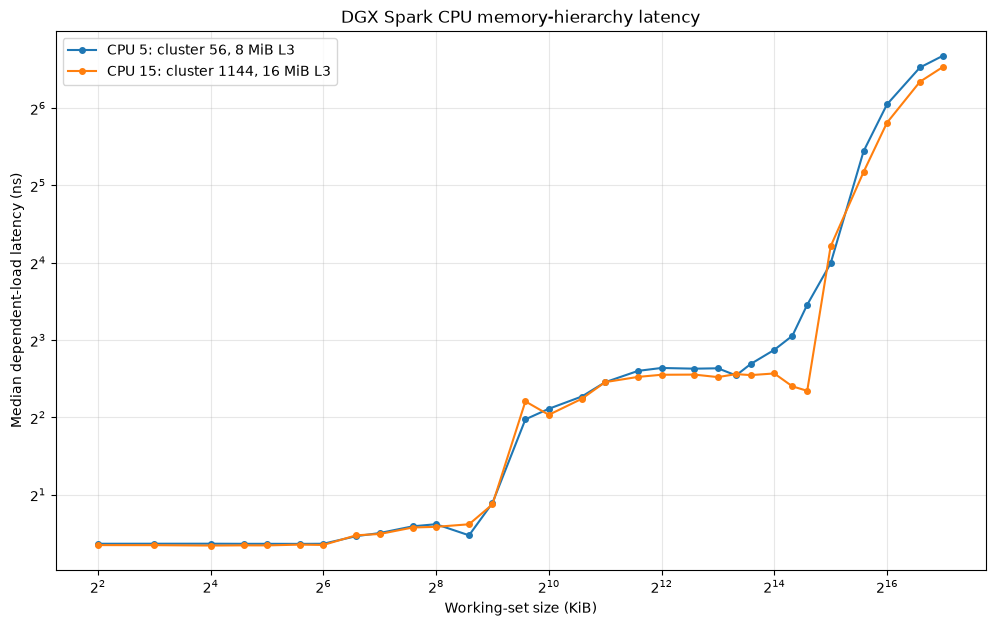

In [11]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(
            f"CPU {cpu_id}: cluster {metadata['cluster_id']}, "
            f"{metadata['l3_mib']} MiB L3"
        ),
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("DGX Spark CPU memory-hierarchy latency")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

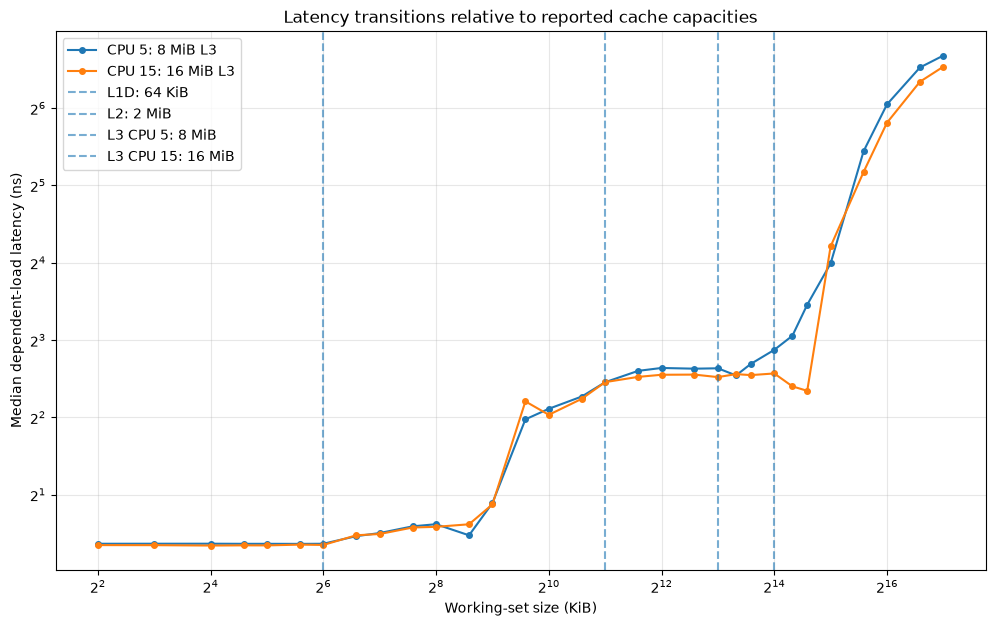

In [12]:
figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(f"CPU {cpu_id}: {metadata['l3_mib']} MiB L3"),
    )

cache_boundaries_kib = {
    "L1D: 64 KiB": 64,
    "L2: 2 MiB": 2 * 1024,
    "L3 CPU 5: 8 MiB": 8 * 1024,
    "L3 CPU 15: 16 MiB": 16 * 1024,
}

for label, boundary_kib in cache_boundaries_kib.items():
    axis.axvline(
        boundary_kib,
        linestyle="--",
        alpha=0.6,
        label=label,
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("Latency transitions relative to reported cache capacities")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

In [13]:
cluster_comparison = latency_summary.pivot(
    index=[
        "working_set_bytes",
        "working_set_kib",
        "working_set_mib",
    ],
    columns="cpu",
    values="median_ns",
).reset_index()

cluster_comparison = cluster_comparison.rename(
    columns={
        5: "cpu_5_latency_ns",
        15: "cpu_15_latency_ns",
    }
)

cluster_comparison["cpu_5_over_cpu_15"] = (
    cluster_comparison["cpu_5_latency_ns"] / cluster_comparison["cpu_15_latency_ns"]
)

cluster_comparison["cpu_15_percent_lower_latency"] = (
    1
    - (cluster_comparison["cpu_15_latency_ns"] / cluster_comparison["cpu_5_latency_ns"])
) * 100

cluster_comparison

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
0,4096,4.0,0.003906,1.288656,1.273149,1.012180,1.203362
1,8192,8.0,0.007812,1.289011,1.272458,1.013009,1.284209
2,16384,16.0,0.015625,1.289248,1.268118,1.016662,1.638909
3,24576,24.0,0.023438,1.287965,1.270432,1.013801,1.361279
4,32768,32.0,0.031250,1.287984,1.269763,1.014350,1.414676
5,49152,48.0,0.046875,1.287264,1.278582,1.006790,0.674423
6,65536,64.0,0.062500,1.288624,1.274998,1.010687,1.057376
7,98304,96.0,0.093750,1.379741,1.390451,0.992297,-0.776262
8,131072,128.0,0.125000,1.418435,1.406435,1.008532,0.846003
9,196608,192.0,0.187500,1.506589,1.490736,1.010634,1.052231


In [14]:
cluster_comparison.query("8 <= working_set_mib <= 20")

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
20,8388608,8192.0,8.0,6.213523,5.741862,1.082144,7.590875
21,10485760,10240.0,10.0,5.829123,5.897686,0.988375,-1.176218
22,12582912,12288.0,12.0,6.464838,5.845424,1.105966,9.581282
23,16777216,16384.0,16.0,7.329600,5.932912,1.235414,19.055446
24,20971520,20480.0,20.0,8.318598,5.284467,1.574160,36.474068


In [15]:
FOCUSED_SIZES = [
    6 * MIB,
    7 * MIB,
    8 * MIB,
    9 * MIB,
    10 * MIB,
    12 * MIB,
    14 * MIB,
    16 * MIB,
    18 * MIB,
    20 * MIB,
    24 * MIB,
    28 * MIB,
    32 * MIB,
    40 * MIB,
    48 * MIB,
]

FOCUSED_REPETITIONS = 10
FOCUSED_ACCESSES = 10_000_000

focused_rows = []

for cpu_id in REPRESENTATIVE_CPUS:
    for working_set_bytes in FOCUSED_SIZES:
        fixed_seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes

        for repetition in range(FOCUSED_REPETITIONS):
            with pinned_to_cpu(cpu_id):
                latency_ns = measure_pointer_chase(
                    working_set_bytes=working_set_bytes,
                    accesses=FOCUSED_ACCESSES,
                    seed=fixed_seed,
                )

            focused_rows.append(
                {
                    "cpu": cpu_id,
                    "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
                    "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
                    "working_set_mib": working_set_bytes / MIB,
                    "repetition": repetition,
                    "latency_ns": latency_ns,
                }
            )

focused_measurements = pd.DataFrame(focused_rows)

In [16]:
focused_summary = focused_measurements.groupby(
    ["cpu", "cluster_id", "l3_mib", "working_set_mib"],
    as_index=False,
).agg(
    minimum_ns=("latency_ns", "min"),
    median_ns=("latency_ns", "median"),
    maximum_ns=("latency_ns", "max"),
    standard_deviation_ns=("latency_ns", "std"),
)

focused_summary

,cpu,cluster_id,l3_mib,working_set_mib,minimum_ns,median_ns,maximum_ns,standard_deviation_ns
0,5,56,8,6.0,6.105021,6.140606,6.212989,0.029965
1,5,56,8,7.0,6.110912,6.161720,6.273683,0.048856
2,5,56,8,8.0,5.940344,5.990540,6.079861,0.038202
3,5,56,8,9.0,5.946096,5.966279,6.040608,0.028184
4,5,56,8,10.0,5.929973,5.972422,6.152798,0.064074
5,5,56,8,12.0,5.801389,5.832766,5.898264,0.035550
6,5,56,8,14.0,5.564984,5.692458,5.786032,0.064370
7,5,56,8,16.0,5.313864,5.573758,6.334138,0.418371
8,5,56,8,18.0,5.386043,5.924082,6.492035,0.563470
9,5,56,8,20.0,5.502902,6.871586,7.113456,0.676415


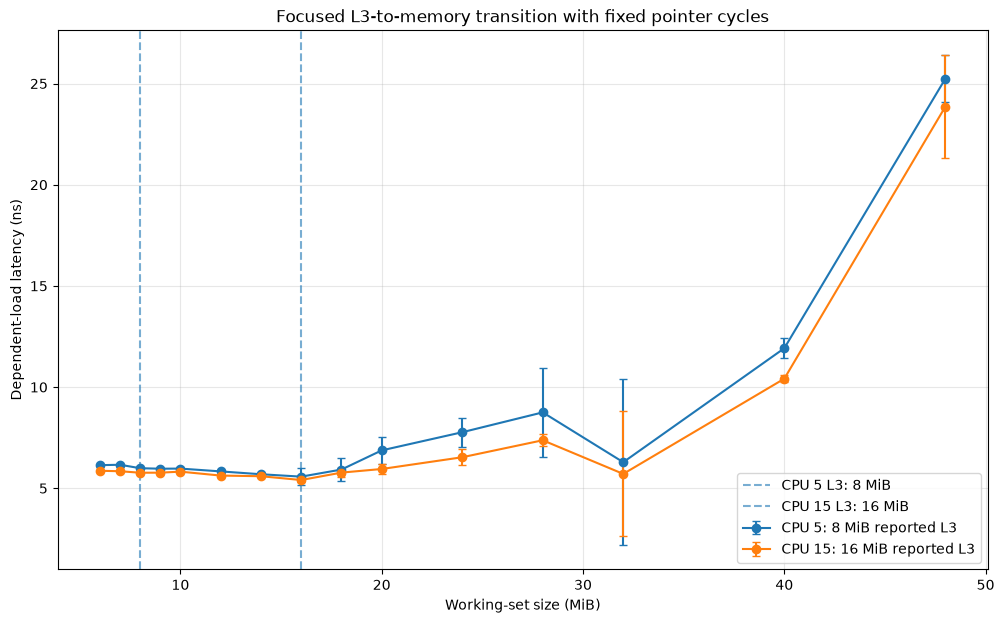

In [17]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, results in focused_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.errorbar(
        results["working_set_mib"],
        results["median_ns"],
        yerr=results["standard_deviation_ns"],
        marker="o",
        capsize=3,
        label=(f"CPU {cpu_id}: {metadata['l3_mib']} MiB reported L3"),
    )

axis.axvline(8, linestyle="--", alpha=0.6, label="CPU 5 L3: 8 MiB")
axis.axvline(16, linestyle="--", alpha=0.6, label="CPU 15 L3: 16 MiB")

axis.set_xlabel("Working-set size (MiB)")
axis.set_ylabel("Dependent-load latency (ns)")
axis.set_title("Focused L3-to-memory transition with fixed pointer cycles")
axis.grid(True, alpha=0.3)
axis.legend()

plt.show()

In [18]:
focused_comparison = focused_summary.pivot(
    index="working_set_mib",
    columns="cpu",
    values="median_ns",
).reset_index()

focused_comparison = focused_comparison.rename(
    columns={
        5: "cpu_5_median_ns",
        15: "cpu_15_median_ns",
    }
)

focused_comparison["cpu_15_percent_lower_latency"] = (
    1 - (focused_comparison["cpu_15_median_ns"] / focused_comparison["cpu_5_median_ns"])
) * 100

focused_comparison

cpu,working_set_mib,cpu_5_median_ns,cpu_15_median_ns,cpu_15_percent_lower_latency
0,6.0,6.140606,5.863966,4.505093
1,7.0,6.161720,5.841572,5.195757
2,8.0,5.990540,5.767669,3.720386
3,9.0,5.966279,5.770275,3.285197
4,10.0,5.972422,5.821167,2.532547
5,12.0,5.832766,5.626790,3.531374
6,14.0,5.692458,5.594796,1.715632
7,16.0,5.573758,5.407270,2.986983
8,18.0,5.924082,5.773380,2.543894
9,20.0,6.871586,5.951867,13.384379


In [19]:
regional_comparison = (
    focused_comparison.assign(
        region=pd.cut(
            focused_comparison["working_set_mib"],
            bins=[0, 8, 16, 32, float("inf")],
            labels=[
                "≤8 MiB",
                "8–16 MiB",
                "16–32 MiB",
                ">32 MiB",
            ],
            include_lowest=True,
        )
    )
    .groupby(
        "region",
        observed=True,
    )
    .agg(
        cpu_5_mean_ns=("cpu_5_median_ns", "mean"),
        cpu_15_mean_ns=("cpu_15_median_ns", "mean"),
        cpu_15_mean_percent_lower_latency=(
            "cpu_15_percent_lower_latency",
            "mean",
        ),
    )
)

regional_comparison

,cpu_5_mean_ns,cpu_15_mean_ns,cpu_15_mean_percent_lower_latency
region,,,
≤8 MiB,6.097622,5.824402,4.473745
8–16 MiB,5.807536,5.644060,2.810347
16–32 MiB,7.120326,6.267774,11.356901
>32 MiB,18.579120,17.135903,9.050830


In [20]:
sequential_read_native = pointer_chase_library.sequential_read_bandwidth

sequential_read_native.argtypes = [
    ctypes.c_size_t,
    ctypes.c_uint64,
]
sequential_read_native.restype = ctypes.c_double


def measure_sequential_bandwidth(
    working_set_bytes: int,
    passes: int,
) -> float:
    bytes_per_second = sequential_read_native(
        working_set_bytes,
        passes,
    )

    if bytes_per_second < 0:
        raise RuntimeError(
            "Native sequential bandwidth benchmark failed "
            f"with result {bytes_per_second}"
        )

    return float(bytes_per_second)

## Observations

The DGX Spark CPU exhibits distinct latency regimes corresponding broadly to private cache, shared cache, and main memory. Dependent-load latency rises from approximately 1.3 ns for small L1-resident working sets to approximately 4 ns in the L2 region, approximately 6 ns in the shared-cache region, and tens to roughly 100 ns for large working sets.

The fixed-layout focused sweep substantially reduced repetition-level variability. The CPU attached to the 16 MiB L3 domain generally exhibited lower dependent-load latency than the CPU attached to the 8 MiB domain, particularly for working sets above approximately 16 MiB. The transition from shared-cache to main-memory behavior was gradual and non-monotonic rather than a sharp boundary at the reported cache capacities. Some working-set sizes, notably 32 MiB, produced unexpectedly low latency on both CPUs, indicating sensitivity to address layout, cache indexing, TLB behavior, or physical-memory mapping.

## Explanation

Cache capacity is not a hard threshold at which every access suddenly becomes a main-memory access. When a randomized working set exceeds cache capacity, some lines may remain resident while others miss, producing an average latency between pure cache-hit and DRAM latency. Set associativity, replacement policy, address hashing, page translation, and physical-memory placement can also make similarly sized working sets behave differently. The larger L3 domain nevertheless provides a repeatable latency advantage over a broad range of larger working sets.

## Connection to LLMs

Memory hierarchy behavior influences embedding lookup, preprocessing, CPU kernels, and movement of model data.

## Further Exploration

TODO: Vary stride, working-set size, and thread placement independently.